# Learner Information Decision-Making Analysis

## 1. Understanding the Dataset

Before analysing the survey responses, we first examine the structure,
size, columns, data types and data quality of the cleaned dataset.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
file_path = "../data/processed/q1_summary_clean.csv"

df = pd.read_csv(file_path)

df.head()

,information_id,information_item,response_category,response_count,percentage
0,1,Description of course/programme (e.g. what sub...,Very useful,810,77.0
1,2,Location of where the course/programme takes p...,Very useful,614,58.0
2,3,How to get to the location of the course/progr...,Very useful,229,22.0
3,4,How to get to the location of the course/progr...,Very useful,394,37.0
4,5,Availability and cost of parking at the provider,Very useful,210,20.0


In [9]:
df.shape

(42, 5)

In [10]:
df.columns

Index(['information_id', 'information_item', 'response_category',
       'response_count', 'percentage'],
      dtype='str')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   information_id     42 non-null     int64  
 1   information_item   42 non-null     str    
 2   response_category  42 non-null     str    
 3   response_count     42 non-null     int64  
 4   percentage         37 non-null     float64
dtypes: float64(1), int64(2), str(2)
memory usage: 1.8 KB


In [12]:
df.isnull().sum()

information_id       0
information_item     0
response_category    0
response_count       0
percentage           5
dtype: int64

In [13]:
df["response_category"].unique()

<StringArray>
[            'Very useful',         'Somewhat useful',
                  'Useful', 'Not particularly useful',
       'Not useful at all',              'Don't know']
Length: 6, dtype: str

In [14]:
df["response_category"].value_counts()

response_category
Very useful                7
Somewhat useful            7
Useful                     7
Not particularly useful    7
Not useful at all          7
Don't know                 7
Name: count, dtype: int64

## Data Quality Check

The dataset was checked for missing values across all columns.

The `information_id`, `information_item`, `response_category`, and
`response_count` columns contain no missing values.

Five values were initially missing from the `percentage` column. These
corresponded to percentages shown as `*%` in the original source data,
indicating very small percentages that were not reported as exact
values.

The missing percentages were calculated using the response counts and
the total number of responses for each information item. The calculated
values were then used to fill the missing percentage values.

A final missing-value check confirmed that all columns now contain
complete data.

In [46]:
df[df["percentage"].isnull()]

,information_id,information_item,response_category,response_count,percentage,analysis_percentage


In [16]:
df[df["information_id"].isin([1, 2, 6])]

,information_id,information_item,response_category,response_count,percentage
0,1,Description of course/programme (e.g. what sub...,Very useful,810,77.0
1,2,Location of where the course/programme takes p...,Very useful,614,58.0
5,6,The length of the course/programme (e.g. the n...,Very useful,672,64.0
7,1,Description of course/programme (e.g. what sub...,Somewhat useful,147,14.0
8,2,Location of where the course/programme takes p...,Somewhat useful,254,24.0
12,6,The length of the course/programme (e.g. the n...,Somewhat useful,246,23.0
14,1,Description of course/programme (e.g. what sub...,Useful,77,7.0
15,2,Location of where the course/programme takes p...,Useful,144,14.0
19,6,The length of the course/programme (e.g. the n...,Useful,111,11.0
21,1,Description of course/programme (e.g. what sub...,Not particularly useful,11,1.0


In [48]:
df.groupby("information_id")["response_count"].sum()

information_id
1    1052
2    1052
3    1052
4    1052
5    1052
6    1052
7    1052
Name: response_count, dtype: int64

In [18]:
df["calculated_percentage"] = (
    df["response_count"]
    / df.groupby("information_id")["response_count"].transform("sum")
    * 100
).round(2)

df.loc[df["percentage"].isna(), [
    "information_id",
    "response_category",
    "response_count",
    "percentage",
    "calculated_percentage"
]]

,information_id,response_category,response_count,percentage,calculated_percentage
28,1,Not useful at all,1,NaN,0.10
29,2,Not useful at all,2,NaN,0.19
33,6,Not useful at all,2,NaN,0.19
36,2,Don't know,4,NaN,0.38
40,6,Don't know,5,NaN,0.48


In [19]:
df["percentage"] = df["percentage"].fillna(df["calculated_percentage"])

df

,information_id,information_item,response_category,response_count,percentage,calculated_percentage
0,1,Description of course/programme (e.g. what sub...,Very useful,810,77.00,77.00
1,2,Location of where the course/programme takes p...,Very useful,614,58.00,58.37
2,3,How to get to the location of the course/progr...,Very useful,229,22.00,21.77
3,4,How to get to the location of the course/progr...,Very useful,394,37.00,37.45
4,5,Availability and cost of parking at the provider,Very useful,210,20.00,19.96
5,6,The length of the course/programme (e.g. the n...,Very useful,672,64.00,63.88
6,7,The number of weekly hours of teaching on the ...,Very useful,517,49.00,49.14
7,1,Description of course/programme (e.g. what sub...,Somewhat useful,147,14.00,13.97
8,2,Location of where the course/programme takes p...,Somewhat useful,254,24.00,24.14
9,3,How to get to the location of the course/progr...,Somewhat useful,247,23.00,23.48


In [47]:
df.isnull().sum()

information_id         0
information_item       0
response_category      0
response_count         0
percentage             0
analysis_percentage    0
dtype: int64

## Response Count Validation

Each information item should contain responses from the same number of
survey participants.

The response counts were grouped by `information_id` and summed to
confirm that each information item contains **1,052 responses**.

This validation helps confirm that no response records have been lost
during the cleaning and transformation process.

In [21]:
df[
    ((df["information_id"] == 1) & (df["response_count"] == 1)) |
    ((df["information_id"] == 2) & (df["response_count"].isin([2, 4]))) |
    ((df["information_id"] == 6) & (df["response_count"].isin([2, 5])))
][[
    "information_id",
    "response_category",
    "response_count",
    "percentage",
    "calculated_percentage"
]]

,information_id,response_category,response_count,percentage,calculated_percentage
28,1,Not useful at all,1,0.10,0.10
29,2,Not useful at all,2,0.19,0.19
33,6,Not useful at all,2,0.19,0.19
36,2,Don't know,4,0.38,0.38
40,6,Don't know,5,0.48,0.48


In [22]:
df = df.drop(columns=["calculated_percentage"])

df.head()

,information_id,information_item,response_category,response_count,percentage
0,1,Description of course/programme (e.g. what sub...,Very useful,810,77.0
1,2,Location of where the course/programme takes p...,Very useful,614,58.0
2,3,How to get to the location of the course/progr...,Very useful,229,22.0
3,4,How to get to the location of the course/progr...,Very useful,394,37.0
4,5,Availability and cost of parking at the provider,Very useful,210,20.0


In [23]:
df.columns

Index(['information_id', 'information_item', 'response_category',
       'response_count', 'percentage'],
      dtype='str')

In [24]:
very_useful = df[df["response_category"] == "Very useful"]

very_useful

,information_id,information_item,response_category,response_count,percentage
0,1,Description of course/programme (e.g. what sub...,Very useful,810,77.0
1,2,Location of where the course/programme takes p...,Very useful,614,58.0
2,3,How to get to the location of the course/progr...,Very useful,229,22.0
3,4,How to get to the location of the course/progr...,Very useful,394,37.0
4,5,Availability and cost of parking at the provider,Very useful,210,20.0
5,6,The length of the course/programme (e.g. the n...,Very useful,672,64.0
6,7,The number of weekly hours of teaching on the ...,Very useful,517,49.0


In [25]:
very_useful_sorted = very_useful.sort_values(
    "percentage",
    ascending=False
)

very_useful_sorted[
    ["information_id", "information_item", "percentage"]
]

,information_id,information_item,percentage
0,1,Description of course/programme (e.g. what sub...,77.0
5,6,The length of the course/programme (e.g. the n...,64.0
1,2,Location of where the course/programme takes p...,58.0
6,7,The number of weekly hours of teaching on the ...,49.0
3,4,How to get to the location of the course/progr...,37.0
2,3,How to get to the location of the course/progr...,22.0
4,5,Availability and cost of parking at the provider,20.0


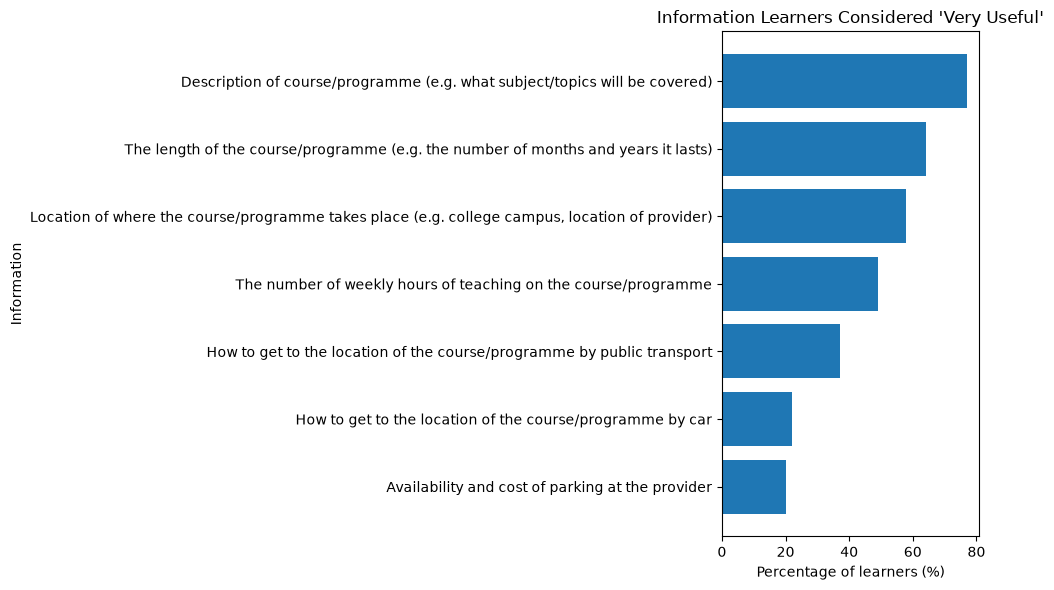

In [26]:
plt.figure(figsize=(10, 6))

plt.barh(
    very_useful_sorted["information_item"],
    very_useful_sorted["percentage"]
)

plt.xlabel("Percentage of learners (%)")
plt.ylabel("Information")
plt.title("Information Learners Considered 'Very Useful'")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [27]:
short_labels = {
    1: "Course description",
    2: "Course location",
    3: "Travel by car",
    4: "Public transport",
    5: "Parking",
    6: "Course length",
    7: "Weekly teaching hours"
}

In [28]:
very_useful_sorted = very_useful_sorted.copy()

very_useful_sorted["short_label"] = (
    very_useful_sorted["information_id"].map(short_labels)
)

very_useful_sorted[
    ["information_id", "short_label", "percentage"]
]

,information_id,short_label,percentage
0,1,Course description,77.0
5,6,Course length,64.0
1,2,Course location,58.0
6,7,Weekly teaching hours,49.0
3,4,Public transport,37.0
2,3,Travel by car,22.0
4,5,Parking,20.0


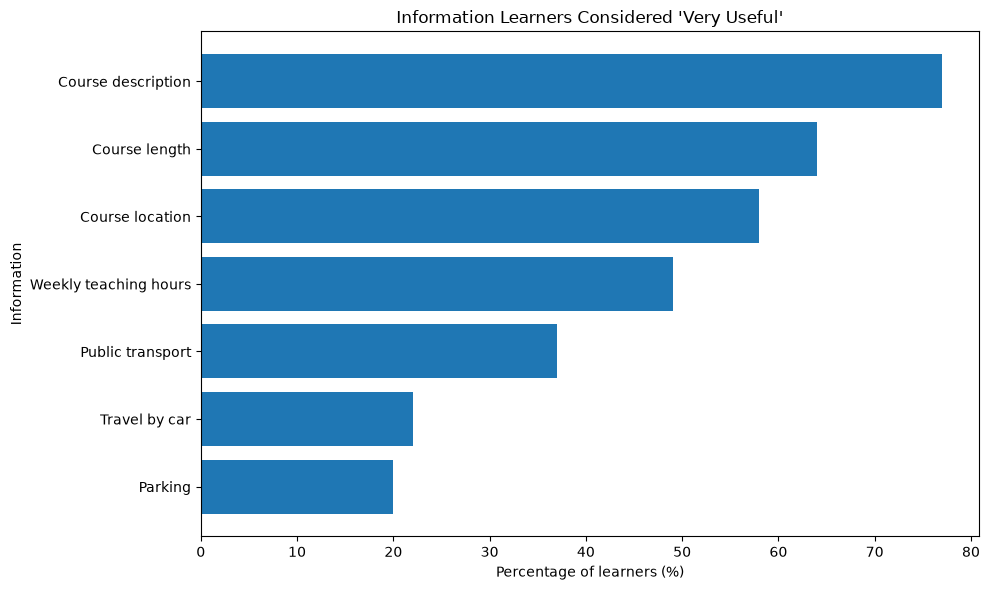

In [29]:
plt.figure(figsize=(10, 6))

plt.barh(
    very_useful_sorted["short_label"],
    very_useful_sorted["percentage"]
)

plt.xlabel("Percentage of learners (%)")
plt.ylabel("Information")
plt.title("Information Learners Considered 'Very Useful'")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

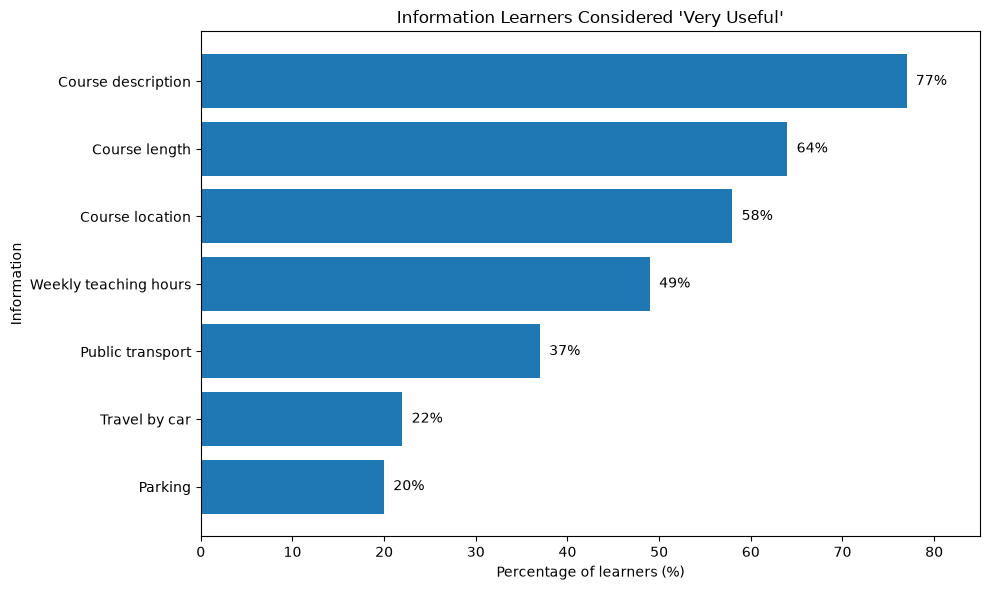

In [30]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    very_useful_sorted["short_label"],
    very_useful_sorted["percentage"]
)

plt.xlabel("Percentage of learners (%)")
plt.ylabel("Information")
plt.title("Information Learners Considered 'Very Useful'")

plt.gca().invert_yaxis()

# Add percentage labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.0f}%",
        va="center"
    )

plt.xlim(0, 85)
plt.tight_layout()
plt.show()

## Key Finding: Information Learners Considered Most Useful

The analysis shows that learners placed the greatest importance on
information about the course itself. **77% of learners** considered the
description of the course/programme "Very useful".

This was followed by information about **course length (64%)** and
**course location (58%)**. Information about **weekly teaching hours
(49%)** was also considered important.

In comparison, fewer learners considered **public transport (37%)**,
**travel by car (22%)**, and **parking availability and cost (20%)**
"Very useful".

Overall, the results suggest that learners prioritised understanding
the **content, duration and location of a course** when making
decisions about which provider or programme to choose.

In [31]:
useful_responses = df[
    df["response_category"].isin(
        ["Very useful", "Somewhat useful"]
    )
]

useful_responses

,information_id,information_item,response_category,response_count,percentage
0,1,Description of course/programme (e.g. what sub...,Very useful,810,77.0
1,2,Location of where the course/programme takes p...,Very useful,614,58.0
2,3,How to get to the location of the course/progr...,Very useful,229,22.0
3,4,How to get to the location of the course/progr...,Very useful,394,37.0
4,5,Availability and cost of parking at the provider,Very useful,210,20.0
5,6,The length of the course/programme (e.g. the n...,Very useful,672,64.0
6,7,The number of weekly hours of teaching on the ...,Very useful,517,49.0
7,1,Description of course/programme (e.g. what sub...,Somewhat useful,147,14.0
8,2,Location of where the course/programme takes p...,Somewhat useful,254,24.0
9,3,How to get to the location of the course/progr...,Somewhat useful,247,23.0


In [32]:
useful_summary = (
    useful_responses
    .groupby(["information_id", "information_item"])["response_count"]
    .sum()
    .reset_index()
)

useful_summary

,information_id,information_item,response_count
0,1,Description of course/programme (e.g. what sub...,957
1,2,Location of where the course/programme takes p...,868
2,3,How to get to the location of the course/progr...,476
3,4,How to get to the location of the course/progr...,699
4,5,Availability and cost of parking at the provider,460
5,6,The length of the course/programme (e.g. the n...,918
6,7,The number of weekly hours of teaching on the ...,862


In [33]:
useful_summary["useful_percentage"] = (
    useful_summary["response_count"] / 1052 * 100
).round(1)

useful_summary

,information_id,information_item,response_count,useful_percentage
0,1,Description of course/programme (e.g. what sub...,957,91.0
1,2,Location of where the course/programme takes p...,868,82.5
2,3,How to get to the location of the course/progr...,476,45.2
3,4,How to get to the location of the course/progr...,699,66.4
4,5,Availability and cost of parking at the provider,460,43.7
5,6,The length of the course/programme (e.g. the n...,918,87.3
6,7,The number of weekly hours of teaching on the ...,862,81.9


In [34]:
useful_summary = useful_summary.sort_values(
    "useful_percentage",
    ascending=False
)

useful_summary[
    ["information_id", "information_item", "response_count", "useful_percentage"]
]

,information_id,information_item,response_count,useful_percentage
0,1,Description of course/programme (e.g. what sub...,957,91.0
5,6,The length of the course/programme (e.g. the n...,918,87.3
1,2,Location of where the course/programme takes p...,868,82.5
6,7,The number of weekly hours of teaching on the ...,862,81.9
3,4,How to get to the location of the course/progr...,699,66.4
2,3,How to get to the location of the course/progr...,476,45.2
4,5,Availability and cost of parking at the provider,460,43.7


In [35]:
useful_summary["short_label"] = (
    useful_summary["information_id"].map(short_labels)
)

useful_summary[
    ["information_id", "short_label", "useful_percentage"]
]

,information_id,short_label,useful_percentage
0,1,Course description,91.0
5,6,Course length,87.3
1,2,Course location,82.5
6,7,Weekly teaching hours,81.9
3,4,Public transport,66.4
2,3,Travel by car,45.2
4,5,Parking,43.7


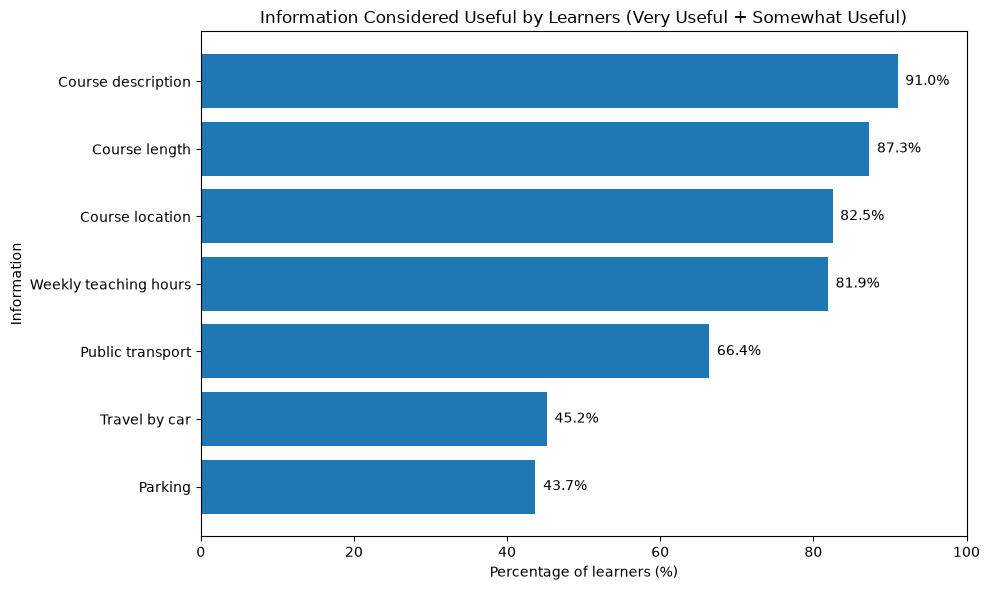

In [36]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    useful_summary["short_label"],
    useful_summary["useful_percentage"]
)

plt.xlabel("Percentage of learners (%)")
plt.ylabel("Information")
plt.title(
    "Information Considered Useful by Learners "
    "(Very Useful + Somewhat Useful)"
)

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center"
    )

plt.xlim(0, 100)
plt.tight_layout()
plt.show()

## Key Finding: Overall Usefulness of Information

When combining the "Very useful" and "Somewhat useful" responses, the
course description was the most highly valued information, with **91.0%**
of learners considering it useful.

Course length (**87.3%**), course location (**82.5%**), and weekly
teaching hours (**81.9%**) were also considered useful by a large
majority of learners.

Public transport information was considered useful by **66.4%** of
learners, while travel by car (**45.2%**) and parking information
(**43.7%**) had lower levels of overall usefulness.

Overall, the results indicate that learners placed greater importance
on information that helps them understand the **course content,
duration, location and time commitment** than on information related to
car travel and parking.

In [37]:
response_distribution = df.pivot(
    index="information_id",
    columns="response_category",
    values="percentage"
)

response_distribution

response_category,Don't know,Not particularly useful,Not useful at all,Somewhat useful,Useful,Very useful
information_id,,,,,,
1,1.00,1.0,0.10,14.0,7.0,77.0
2,0.38,3.0,0.19,24.0,14.0,58.0
3,1.00,18.0,6.00,23.0,31.0,22.0
4,1.00,9.0,2.00,29.0,22.0,37.0
5,2.00,19.0,9.00,24.0,26.0,20.0
6,0.48,2.0,0.19,23.0,11.0,64.0
7,1.00,3.0,1.00,33.0,13.0,49.0


In [38]:
response_distribution.sum(axis=1)

information_id
1    100.10
2     99.57
3    101.00
4    100.00
5    100.00
6    100.67
7    100.00
dtype: float64

In [39]:
df["analysis_percentage"] = (
    df["response_count"]
    / df.groupby("information_id")["response_count"].transform("sum")
    * 100
).round(2)

df.head()

,information_id,information_item,response_category,response_count,percentage,analysis_percentage
0,1,Description of course/programme (e.g. what sub...,Very useful,810,77.0,77.00
1,2,Location of where the course/programme takes p...,Very useful,614,58.0,58.37
2,3,How to get to the location of the course/progr...,Very useful,229,22.0,21.77
3,4,How to get to the location of the course/progr...,Very useful,394,37.0,37.45
4,5,Availability and cost of parking at the provider,Very useful,210,20.0,19.96


In [40]:
analysis_distribution = df.pivot(
    index="information_id",
    columns="response_category",
    values="analysis_percentage"
)

analysis_distribution.sum(axis=1)

information_id
1    100.01
2    100.00
3    100.01
4    100.00
5    100.00
6    100.00
7    100.00
dtype: float64

In [41]:
response_order = [
    "Very useful",
    "Somewhat useful",
    "Useful",
    "Not particularly useful",
    "Not useful at all",
    "Don't know"
]

analysis_distribution = analysis_distribution[
    response_order
]

analysis_distribution

response_category,Very useful,Somewhat useful,Useful,Not particularly useful,Not useful at all,Don't know
information_id,,,,,,
1,77.00,13.97,7.32,1.05,0.10,0.57
2,58.37,24.14,13.69,3.23,0.19,0.38
3,21.77,23.48,30.51,17.78,5.61,0.86
4,37.45,28.99,22.43,8.94,1.62,0.57
5,19.96,23.76,25.57,19.30,9.03,2.38
6,63.88,23.38,10.55,1.52,0.19,0.48
7,49.14,32.79,13.12,3.33,0.95,0.67


In [42]:
analysis_distribution["short_label"] = (
    analysis_distribution.index.map(short_labels)
)

analysis_distribution

response_category,Very useful,Somewhat useful,Useful,Not particularly useful,Not useful at all,Don't know,short_label
information_id,,,,,,,
1,77.00,13.97,7.32,1.05,0.10,0.57,Course description
2,58.37,24.14,13.69,3.23,0.19,0.38,Course location
3,21.77,23.48,30.51,17.78,5.61,0.86,Travel by car
4,37.45,28.99,22.43,8.94,1.62,0.57,Public transport
5,19.96,23.76,25.57,19.30,9.03,2.38,Parking
6,63.88,23.38,10.55,1.52,0.19,0.48,Course length
7,49.14,32.79,13.12,3.33,0.95,0.67,Weekly teaching hours


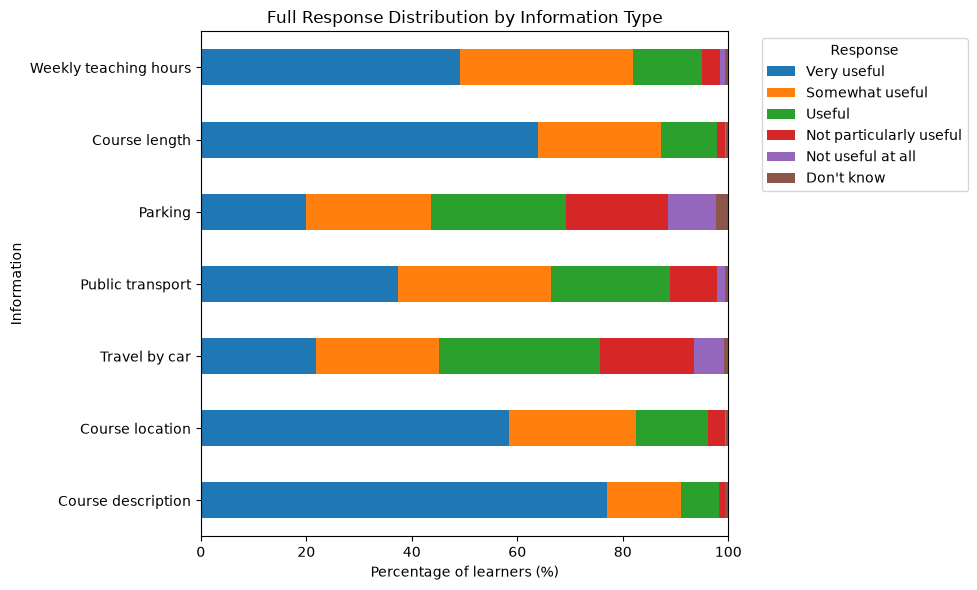

In [43]:
plot_data = analysis_distribution.set_index("short_label")

ax = plot_data.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 6)
)

plt.xlabel("Percentage of learners (%)")
plt.ylabel("Information")
plt.title("Full Response Distribution by Information Type")

plt.legend(
    title="Response",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.xlim(0, 100)

plt.tight_layout()
plt.show()

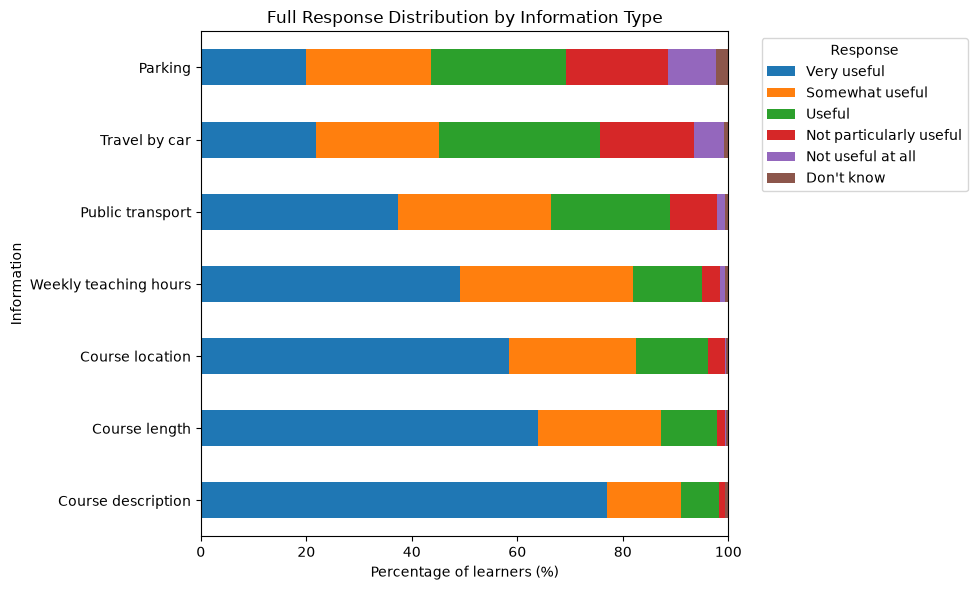

In [44]:
plot_data = analysis_distribution.set_index("short_label")

plot_order = [
    "Course description",
    "Course length",
    "Course location",
    "Weekly teaching hours",
    "Public transport",
    "Travel by car",
    "Parking"
]

plot_data = plot_data.reindex(plot_order)

ax = plot_data.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 6)
)

plt.xlabel("Percentage of learners (%)")
plt.ylabel("Information")
plt.title("Full Response Distribution by Information Type")

plt.legend(
    title="Response",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.xlim(0, 100)

plt.tight_layout()
plt.show()

## Key Finding: Full Response Distribution

The full response distribution provides a more detailed view of how
learners assessed each type of information.

Information about the **course description** received the strongest
positive response, with **77.0%** of learners rating it "Very useful"
and a further **14.0%** rating it "Somewhat useful".

**Course length** and **course location** also received predominantly
positive responses, with 87.3% and 82.5% respectively rating these
types of information as either "Very useful" or "Somewhat useful".

In contrast, responses relating to **travel by car** and **parking**
were more widely distributed across the response categories. Parking
had the highest proportion of "Not useful at all" responses at
approximately **9.0%**.

Overall, the distribution shows that learners placed greater value on
information directly related to the **course itself and the commitment
involved**, while transport and parking information received more mixed
responses.